# CVL Assignment 1

```
Name          : Shadiq Arif Aryasatya
NIM           : 24/536702/PA/22763
Class         : CS
Subject       : Computer Vision and Image Analysis
```

For this assignment, I have chosen to use the Histogram Equalization method to enhance an image that is too dark. To begin, we load in the image, set it properly, and list all the pixels that make it.

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('dark_matthew.jpeg').convert('L')
width, height = img.size
pixels = list(img.getdata())

Next, we build the histogram by creating a list of zeros to represent the intensity values between 0 and 255.

In [3]:
hist = [0] * 256
for p in pixels:
    hist[p] += 1

After that, we calculate the Cumulative Distribution Function (CDF), which tells us the rank of each intensity.

In [ ]:
cdf = [0] * 256
cumulative_sum = 0
for i in range(256):
    cumulative_sum += hist[i]
    cdf[i] = cumulative_sum

The next step is to create a Look-Up Table (LUT), which maps the intensity of the old histogram to one that's equalized. This is done by using two formulas. The first is a Probability Mass Function (PMF), which is the probability of a random pixel in the image having a specific intensity rk.

```
Pr(rk) = nk/MN

nk = number of pixels with an intensity of rk
MN = total number of pixels in the image (length x width)
```
The second formula is a transformation maps an input pixel r to an output pixel s.

```
sk = T(rk) = (L - 1) sigma^k_(j = 0) Pr(rj)

sk = new pixel value
L - 1 = maximum intensity level
sigma^k_(j = 0) Pr(rj) = The CDF, which sums the probabilities of all intensities from 0 up to the current intensity k
```

In [ ]:
min_cdf = min([c for c in cdf if c > 0])
total_pixels = width * height
lut = [0] * 256

for i in range(256):
    val = (cdf[i] - min_cdf) / (total_pixels - min_cdf)
    lut[i] = int(val * 255)

After that, the pixels with new intensities are listed and the image is reconstructed to be visualized.

In [ ]:
new_pixels = [lut[p] for p in pixels]

en_img = Image.new('L', (width, height))
en_img.putdata(new_pixels)

Finally, the last step is to visualize the enhanced image along with the histrogram.

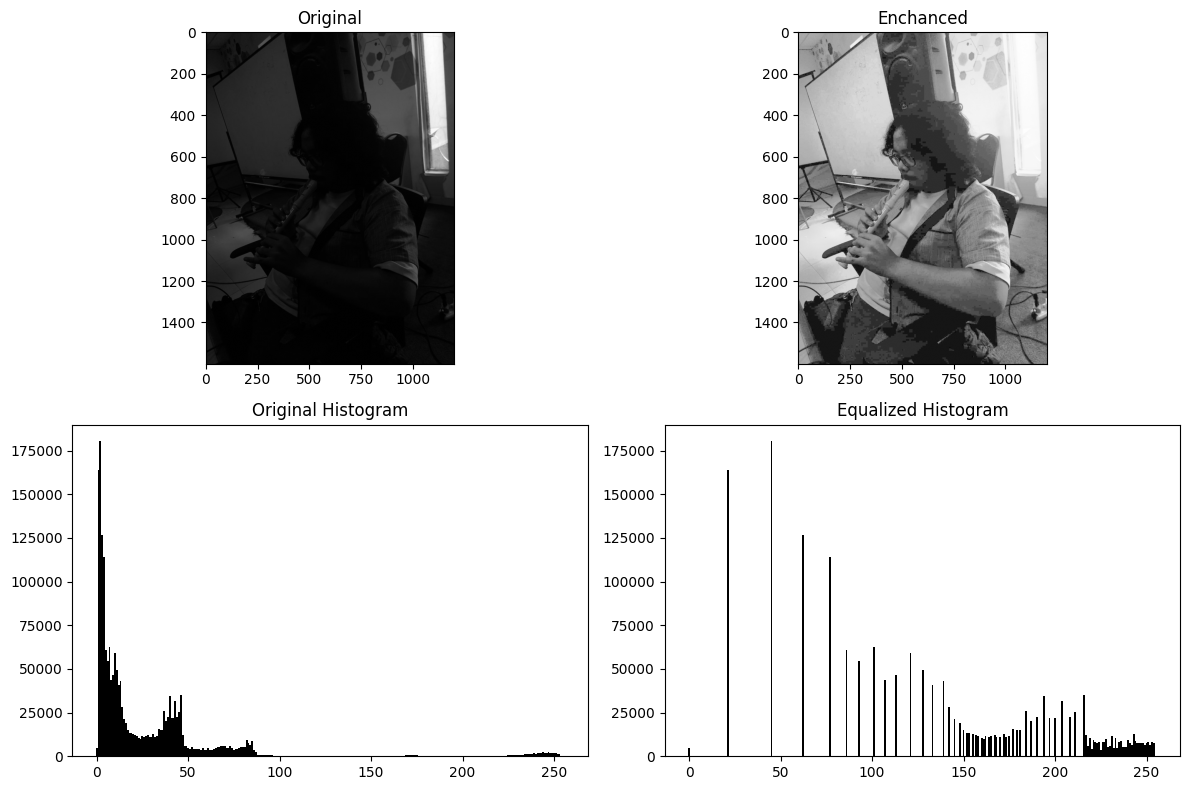

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set_title("Original")
axs[0, 1].imshow(en_img, cmap='gray')
axs[0, 1].set_title("Enchanced")

axs[1, 0].bar(range(256), hist, color='black', width=1)
axs[1, 0].set_title("Original Histogram")
axs[1, 1].bar(range(256), [new_pixels.count(i) for i in range(256)], color='black', width=1)
axs[1, 1].set_title("Equalized Histogram")

plt.tight_layout()
plt.show()

And with that, the dark image is enhanced using histogram equalization.